## 2.4.微积分
### 2.4.1.导数和微分
下面定义$u=f(x)=3x^{2}-4x$如下:

In [2]:
%pip install matplotlib

Could not fetch URL https://pypi.org/simple/pip/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/pip/ (Caused by SSLError(SSLEOFError(8, 'EOF occurred in violation of protocol (_ssl.c:1131)'))) - skipping
Note: you may need to restart the kernel to use updated packages.


In [3]:
%matplotlib inline 
import numpy as np 
from matplotlib_inline import backend_inline
from d2l import torch as d2l
def f(x):
    return 3 * x ** 2 - 4 * x

In [4]:
def numerical_lim(f,x,h):
    return (f(x+h)-f(x))/h
h = 0.1
for i in range(5):
    print(f'h={h:.5f},numerical limit = {numerical_lim(f,1,h):.5f}')
    h *= 0.1

h=0.10000,numerical limit = 2.30000
h=0.01000,numerical limit = 2.03000
h=0.00100,numerical limit = 2.00300
h=0.00010,numerical limit = 2.00030
h=0.00001,numerical limit = 2.00003


为了对导数的这种解释进行可视化，我们将使用matplotlib， 这是一个Python中流行的绘图库。 要配置matplotlib生成图形的属性，我们需要定义几个函数。 在下面，use_svg_display函数指定matplotlib软件包输出svg图表以获得更清晰的图像。

注意，注释#@save是一个特殊的标记，会将对应的函数、类或语句保存在d2l包中。 因此，以后无须重新定义就可以直接调用它们（例如，d2l.use_svg_display()）。

In [5]:
def use_svg_display(): #@save
    backend_inline.set_matplotlib_formats('svg')

定义set_figsize函数来设置图表大小。注意，这里可以直接使用d2l.plt，因为导入语句 from matplotlib import pyplot as plt已标记为保存到d2l包中。

In [6]:
def set_figsize(figsize=(3.5,3.5)): #@save
    use_svg_display()
    d2l.plt.rcParams['figure.figsize'] = figsize

下面的set_axes函数用于设置由matplotlib生成的轴的属性

In [7]:
#@save
def set_axes(axes,xlabel,ylabel,xlim,ylim,xscale,yscale,legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

通过这三个用于图形配置的函数，定义一个plot函数来简洁地绘制多条曲线

In [8]:
#@save
def plot(X, Y=None, xlabel=None, ylabel=None, legend=None, xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(6, 7), axes=None):
    """绘制数据点"""
    if legend is None:
        legend = []

    set_figsize(figsize)
    axes = axes if axes else d2l.plt.gca() # 如果未传入axes的值则获取画布当前的axes

    # 如果X有一个轴，输出True
    def has_one_axis(X):
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X):
        X = [X] # 如果是一个轴，将其列表化
    if Y is None:
        X, Y = [[]] * len(X), X # 如果没有传入Y参数，X为包含X长度个空列表的大列表，Y为X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y) # 如果X的长度和Y的长度不一样，X改为Y长度数个X
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        if len(x):
            axes.plot(x, y, fmt)
        else:
            axes.plot(y, fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

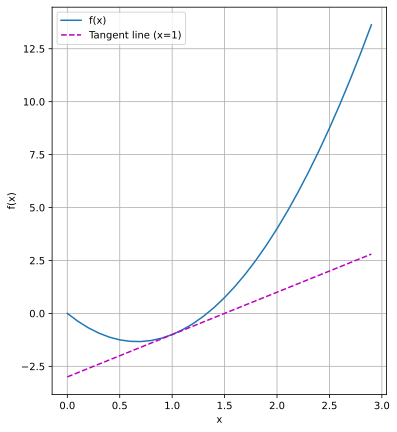

In [9]:
x = np.arange(0, 3, 0.1)
plot(x, [f(x), 2 * x - 3], 'x', 'f(x)', legend=['f(x)', 'Tangent line (x=1)'])

C:\Users\YuHxx\AppData\Local\Temp\ipykernel_19324\2391542972.py:2: RuntimeWarning: divide by zero encountered in divide
  plot(x,[x**3-1/x,4*x-4],'x','f(x)',legend=['f(x)','Tangent line (x=1)'])


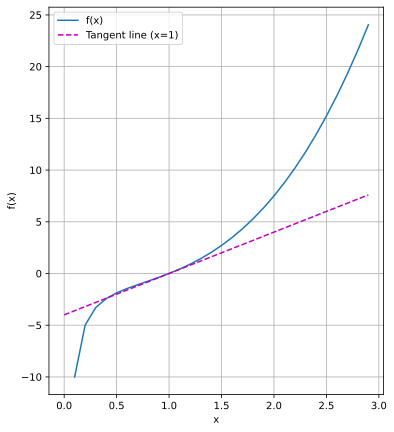

In [13]:
# 绘制函数 y = f(x) = x^3 - 1/x 和其在x=1处切线图像
plot(x,[x**3-1/x,4*x-4],'x','f(x)',legend=['f(x)','Tangent line (x=1)'])

### 2.4.2.梯度
我们可以连结一个多元函数对其所有变量的偏导数，以得到该函数的梯度（gradient）向量。 函数$f(x)$相对于$x$的梯度是一个包含$n$个偏导数的向量:$$\nabla_{\mathbf{x}}f(\mathbf{x})=\left[\frac{\partial f(\mathbf{x})}{\partial x_1},\frac{\partial f(\mathbf{x})}{\partial x_2},\ldots,\frac{\partial f(\mathbf{x})}{\partial x_n}\right]^\top,$$其中$\nabla_{\mathbf{x}f(\mathbf{x})}$通常在没有歧义时被$\nabla f(\mathbf{x})$取代。
